# Checking concept spread types on unseen and medical data: the type × rooting step

This notebook is a runnable demo of one step of the evaluation of the frozen RQ2 descriptive layer (artifact `art_mu0h0npvNX_u`). That layer holds the k=2 diffusion typology, community roles, lead-lag and emergence patterns.

The evaluation's `eval.py` is a thin orchestrator. It runs the step modules in `evalsteps/` in order: `typology rooting mesh leadlag confirmation cases figures assemble`. Most steps read the frozen experiment copy (`exp8_frozen/`) and the one-time held-out opening, which stay on the run's volume. This demo runs the **`rooting` step** (`evalsteps/rooting.py`, "STEP 2c/2d"), which is the new result of the evaluation.

It joins each concept's frozen **type** (BROAD = "broad from the start", or LOCALISED) to its D2 **host entries**. A host entry is the first time the concept appears in a new host subfield `d` in year `e`. It then asks:

* **Occupancy.** Do BROAD concepts enter more hosts?
* **Host share (`A_cont`).** Do BROAD concepts enter with a higher share of host-native companions? This was the declared prediction, and in the full run it was *not supported* once host × year FE are added.
* **Co-transfer (`CT`).** Do BROAD concepts carry fewer co-transferred concepts? This was declared, and it *replicated* out of sample: −0.126 on the screen and −0.125 on held-out.
* **Host share and rooting within each type.** A PPML model of `Y_strict` (W2 persistence) on `A_cont × BROAD`.
* **Lagged role.** Host share by the concept's robust role one year earlier.

**Data.** `mini_demo_data.json` holds 100 concepts from the evaluation's saved samples: 60 from the screen fold (30 BROAD / 30 LOCALISED) and 40 from the held-out W1 fold (20 / 20). The full run used 184 screen and 93 held-out concepts. For these concepts the file holds their D2 co-primary host entries, their all-MAIN entry rows (used for occupancy) and their concept-year role rows. Held-out rows carry **W1 features only**, because D2's W2 outcome stays sealed. Numbers here are therefore noisier than the full-run values quoted above.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pyfixest (fixed-effects OLS), loguru (logging used by the original step) — NOT on Colab, always install
_pip('pyfixest==0.60.0', 'loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports
The import block of `evalsteps/base.py` and `evalsteps/rooting.py`, plus `matplotlib` for the final plots.

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

import matplotlib.pyplot as plt

## Data loading
The data is read from the GitHub repository, with a fallback to a local copy of `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_F1tk5OGtH84L/round-4/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: len(v) for k, v in data.items() if isinstance(v, list)})

Mini subset of the RQ2 type x rooting evaluation (evalsteps/rooting.py): D2 host entries (co-primary sample: arm main, kw5, MAIN, complete controls) joined to the frozen k=2 diffusion type, for 60 screen concepts (30 BROAD / 30 LOCALISED) and 40 held-out concepts (20/20, W1 columns only: no outcomes); plus all-MAIN entry rows (occupancy) and lagged community roles.
{'screen_entries': 690, 'heldout_entries_W1': 584, 'all_main_screen': 788, 'all_main_heldout': 665, 'roles_screen': 863, 'roles_heldout': 574}


## Config
The tunable parameters, all set to the original step's values: a 2,000-draw concept-cluster bootstrap for the per-type descriptives, a 1,000-draw bootstrap for the per-role tables, and PPML with `maxit=500, tol=1e-12`. On the 100-concept demo subset the whole notebook runs in about a minute. For a quicker look, lower the bootstrap sizes (e.g. 200 / 100). Point estimates do not change, only the CIs get coarser.

In [5]:
B_DESCRIPTIVES = 2000  # concept-cluster bootstrap draws for per-type stats and BROAD - LOCALISED diffs (original: 2000)
B_ROLES = 1000         # bootstrap draws for host share per lagged role / GA class (original: 1000)
PPML_MAXIT = 500       # PPML IRLS iterations (original: 500)
PPML_TOL = 1e-12       # PPML convergence tolerance (original: 1e-12)

## Shared helpers (`evalsteps/base.py`)
These are the type labels of the frozen k=2 typology and the concept-cluster bootstrap. The bootstrap resamples whole concepts, so all of a concept's host entries enter or leave together. The file-path constants (`WS`, `E7`, `E8`, `HO`, …) are left out because the notebook reads everything from `data`.

In [6]:
BROAD = "broad from the start (rapid interdisciplinary)"
LOCAL = "localised"
TYPE_SHORT = {BROAD: "BROAD", LOCAL: "LOCALISED"}
Z = 1.959964


def sha256(p: Path) -> str:
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()


def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if not math.isfinite(v) else v
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return clean(o.tolist())
    if o is pd.NA or o is pd.NaT:
        return None
    return o


def cluster_boot_many(df: pd.DataFrame, stats: dict, cluster: str = "concept_id", B: int = 2000, seed: int = 0) -> dict:
    """Same resamples for several statistics (faster, index-based)."""
    codes, uniq = pd.factorize(df[cluster])
    idx_by = [np.flatnonzero(codes == i) for i in range(len(uniq))]
    rng = np.random.default_rng(seed)
    obs = {k: f(df) for k, f in stats.items()}
    draws = {k: [] for k in stats}
    for _ in range(B):
        pick = rng.integers(0, len(uniq), len(uniq))
        rows = np.concatenate([idx_by[i] for i in pick])
        d = df.iloc[rows]
        for k, f in stats.items():
            v = f(d)
            if v is not None and np.isfinite(v):
                draws[k].append(v)
    return {k: dict(est=obs[k], ci=(np.percentile(draws[k], [2.5, 97.5]).tolist() if draws[k] else [None, None]),
                    B=B, n_clusters=len(uniq), n_rows=len(df)) for k in stats}

## Frozen PPML estimator (`ppml.py` from the D2 experiment `art_2Cd2JJypeGuA`)
`rooting.py` imports this module from the D2 experiment's `src/`. It is copied here verbatim, apart from `wild_score_test`, which this step does not use. It fits Poisson pseudo-ML with several high-dimensional fixed effects. The fit uses IRLS with an exact weighted projection off the FE space and reports CRV1 (concept-clustered) standard errors.

In [7]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


import types
ppml = types.SimpleNamespace(fit=fit)  # stands in for `import ppml` (the D2 module) inside ppml_interaction below

## `rooting.py`: sample definition
`d2_sample` reuses the D2 co-primary sample definition verbatim. The filters are arm `main`, the given fold, `kw5` (at least 5 partner concepts) and `MAIN`, and complete event and secondary controls are required.

`FORBIDDEN` lists outcome and W2 column prefixes. The original `load_heldout_w1()` checked the sealed held-out feature file's sha256 and asserted that none of these columns were present. The demo data was extracted from the evaluation's already-checked held-out sample. The same assertion is repeated below when the held-out frame is built.

In [8]:
CTRL_EVENT = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share", "abstract_share"]
CTRL_SEC = ["mom_d", "log_centrality", "log_W1"]
FORBIDDEN = ("Y_", "EST", "n_w2", "w2_", "present_")


def d2_sample(df: pd.DataFrame, fold: str) -> pd.DataFrame:
    s = df[(df.arm == "main") & (df.fold == fold) & df.kw5 & df.MAIN].copy()
    need = ["A_cont", "CT"] + CTRL_EVENT + CTRL_SEC
    return s.dropna(subset=[c for c in need if c in s.columns]).reset_index(drop=True)

## `rooting.py`: per-type descriptives
For each type the step computes concept-cluster bootstrap CIs for the following:

* mean host share `A_cont`, both entry-weighted and concept-averaged;
* excess anchoring `A_cont − A0_cont`;
* co-transfer `CT`;
* the share of anchored graft labels;
* on the screen only, the W2 outcomes `Y_strict`, `EST_bin` and the rooted share.

It also computes occupancy (entries per concept) and a type-stratified bootstrap of the BROAD − LOCALISED difference.

In [9]:
def descriptives(s: pd.DataFrame, all_main: pd.DataFrame, with_outcomes: bool, B: int = 2000) -> dict:
    out = {}
    for t, g in s.groupby("type"):
        stats = {"A_cont_mean": lambda d: d.A_cont.mean(), "A_cont_concept_avg": lambda d: d.groupby("concept_id").A_cont.mean().mean(),
                 "excess_A": lambda d: (d.A_cont - d.A0_cont).mean(), "CT_mean": lambda d: d.CT.mean(),
                 "anchored_share": lambda d: d.anchored.astype(float).mean() if d.anchored.notna().any() else np.nan}
        if with_outcomes:
            stats.update({"Y_strict_mean": lambda d: d.Y_strict.mean(), "Y_pos_share": lambda d: (d.Y_strict > 0).mean(),
                          "EST_rate": lambda d: d.EST_bin.mean(), "rooted_share": lambda d: d.groupby("concept_id").EST_bin.mean().mean()})
        b = cluster_boot_many(g, stats, B=B, seed=1)
        b["A_cont_median"] = float(g.A_cont.median())
        b["n_entries"] = len(g)
        b["n_concepts"] = int(g.concept_id.nunique())
        out[t] = b
    # occupancy: entries per concept, all MAIN kw-any entries and co-primary sample (concepts with 0 entries included)
    occ = {}
    for t in ("BROAD", "LOCALISED"):
        a = all_main[all_main.type == t]
        occ[t] = dict(all_main_entries_per_concept=float(a.groupby("concept_id").size().mean()) if len(a) else None,
                      coprimary_entries_per_concept=float(s[s.type == t].groupby("concept_id").size().mean()) if (s.type == t).any() else None)
    out["occupancy"] = occ
    # type difference (BROAD - LOCALISED) by concept-cluster bootstrap, stratified by type
    diffs = {}
    keys = ["A_cont", "CT"] + (["Y_strict", "EST_bin"] if with_outcomes else [])
    rng = np.random.default_rng(7)
    gb = {t: {c: g for c, g in s[s.type == t].groupby("concept_id")} for t in ("BROAD", "LOCALISED")}
    obs = {k: s[s.type == "BROAD"][k].mean() - s[s.type == "LOCALISED"][k].mean() for k in keys}
    draws = {k: [] for k in keys}
    for _ in range(B):
        m = {}
        for t in ("BROAD", "LOCALISED"):
            cs = list(gb[t])
            pick = rng.integers(0, len(cs), len(cs))
            m[t] = pd.concat([gb[t][cs[i]] for i in pick])
        for k in keys:
            draws[k].append(m["BROAD"][k].mean() - m["LOCALISED"][k].mean())
    for k in keys:
        diffs[k] = dict(diff=obs[k], ci=np.percentile(draws[k], [2.5, 97.5]).tolist())
    out["diff_BROAD_minus_LOCALISED"] = diffs
    return out

## `rooting.py`: models (i) and (ii), fixed-effects OLS
`y ~ BROAD + log_n_partner_tags + RD | host × entry-year FE`, with concept-clustered SEs. Comparing entries into the *same host in the same year* removes the fact that BROAD concepts enter different, larger hosts. In the full run, this is what turns the raw negative `A_cont` gap into a null. When folds are pooled, a fold dummy is added.

In [10]:
def feols(s: pd.DataFrame, y: str) -> dict:
    import pyfixest as pf
    d = s.copy()
    d["BROAD"] = (d.type == "BROAD").astype(float)
    d["dxe"] = d.d.astype(str) + "_" + d.e.astype(str)
    extra = " + C(fold)" if d.fold.nunique() > 1 else ""
    f = pf.feols(f"{y} ~ BROAD + log_n_partner_tags + RD{extra} | dxe", data=d, vcov={"CRV1": "concept_id"})
    t = f.tidy()
    r = t.loc["BROAD"]
    return dict(y=y, n=int(f._N), n_concepts=int(d.concept_id.nunique()), coef=float(r["Estimate"]), se=float(r["Std. Error"]),
                p=float(r["Pr(>|t|)"]), ci=[float(r["2.5%"]), float(r["97.5%"])], sd_y=float(d[y].std()),
                coef_in_sd=float(r["Estimate"]) / float(d[y].std()), fe="host x entry year (d x e)", cluster="concept")

## `rooting.py`: model (iii), PPML interaction (exploratory, screen only)
`Y_strict ~ A_cont + A_cont×BROAD + CT + D2 controls | concept + entry-year + host FE`, with offset `log(n_entry_papers)`. The second fit splits the `A_cont` slope by type and reports the IRR per SD of `A_cont` within BROAD and within LOCALISED. The full run found 1.36 vs 1.16, with interaction p = 0.11. The only change from the original is that the `sys.path` / `import ppml` lines are commented out, because `ppml` was defined above.

In [11]:
def ppml_interaction(s: pd.DataFrame) -> dict:
    # import sys
    # sys.path.insert(0, str(E7 / "src"))
    # import ppml
    d = s.copy()
    d["BROAD"] = (d.type == "BROAD").astype(float)
    sdA = d.A_cont.std()
    d["A_x_BROAD"] = d.A_cont * d.BROAD
    xv = ["A_cont", "A_x_BROAD", "CT"] + CTRL_EVENT + CTRL_SEC
    fes = [pd.factorize(d.concept_id)[0], pd.factorize(d.e.astype(str))[0], pd.factorize(d.d.astype(str))[0]]
    off = np.log(d.n_entry_papers.astype(float).to_numpy())
    r = ppml.fit(d.Y_strict.to_numpy(float), d[xv].to_numpy(float), fes, off, d.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    d["A_x_LOCAL"] = d.A_cont * (1 - d.BROAD)
    xv2 = ["A_x_LOCAL", "A_x_BROAD", "CT"] + CTRL_EVENT + CTRL_SEC
    r2 = ppml.fit(d.Y_strict.to_numpy(float), d[xv2].to_numpy(float), fes, off, d.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    if r is None or r2 is None:
        return dict(note="PPML did not converge")
    from scipy.stats import norm
    bi, sei = float(r["coef"][1]), float(r["se"][1])
    irr = lambda bb, se: dict(coef=float(bb), se=float(se), irr_per_sd=float(np.exp(bb * sdA)),
                              ci=[float(np.exp((bb - 1.96 * se) * sdA)), float(np.exp((bb + 1.96 * se) * sdA))],
                              p=float(2 * norm.sf(abs(bb / se))))
    return dict(n_retained=int(r["n"]), G=int(r["G"]), sd_A_cont=float(sdA), LOCALISED=irr(r2["coef"][0], r2["se"][0]),
                BROAD=irr(r2["coef"][1], r2["se"][1]), interaction_coef=bi, interaction_se=sei,
                interaction_p=float(2 * norm.sf(abs(bi / sei))), fe="concept + e + host (D2 co-primary)",
                note="exploratory; type main effect absorbed by concept FE")

## `rooting.py`: host share per lagged role
The concept's robust role in year `e−1` is attached to each entry in year `e`. This is its modal role across Leiden seeds, or `NONROBUST` if the seeds disagree. The step then tabulates mean `A_cont`, `CT` and (screen only) the establishment rate by role and by GA class. The only change is that `B=1000` became `B=B_ROLES`.

In [12]:
def role_host_share(ev: pd.DataFrame, roles: pd.DataFrame, with_outcomes: bool) -> dict:
    r = roles[["concept_id", "year", "role_modal", "robust", "GA_class"]].copy()
    r["role_lag"] = np.where(r.robust, r.role_modal, "NONROBUST")
    r["year"] = r.year + 1  # role in e-1 attaches to entry year e
    m = ev.merge(r.rename(columns={"year": "e"}), on=["concept_id", "e"], how="left")
    m["role_lag"] = m.role_lag.fillna("NO_ROLE_ROW")
    m["GA_class"] = m.GA_class.fillna("NO_ROLE_ROW")
    out = {}
    for by in ("role_lag", "GA_class"):
        tab = {}
        for k, g in m.groupby(by):
            st = {"A_cont": lambda d: d.A_cont.mean(), "CT": lambda d: d.CT.mean()}
            if with_outcomes:
                st["EST_rate"] = lambda d: d.EST_bin.mean()
            b = cluster_boot_many(g, st, B=B_ROLES, seed=3)
            b["n_entries"] = len(g)
            b["n_concepts"] = int(g.concept_id.nunique())
            tab[str(k)] = b
        out[by] = tab
    return out

## Build the input frames from `data`
This replaces the parquet reads in `run()`. The original read the D2 screen events, merged the graft labels and mapped the frozen typology `cluster_name` to BROAD/LOCALISED. In the demo data, each entry row already carries `type` and `anchored`.

The all-MAIN entry rows (`all_main_screen`, `all_main_heldout`) are already filtered to arm `main`, `MAIN` and typed concepts. They play the role of `all_main_s` / `all_main_h` in the occupancy line.

In [13]:
ev = pd.DataFrame(data["screen_entries"])            # original: E7 screen_events_with_outcomes.parquet + graft labels + type
h = pd.DataFrame(data["heldout_entries_W1"])         # original: load_heldout_w1() + sealed graft labels + held-out type
all_main_s = pd.DataFrame(data["all_main_screen"])   # all MAIN entries (occupancy), screen
all_main_h = pd.DataFrame(data["all_main_heldout"])  # all MAIN entries (occupancy), held-out
roles_s = pd.DataFrame(data["roles_screen"])         # original: exp8_frozen/results/roles.parquet
roles_h = pd.DataFrame(data["roles_heldout"])        # original: exp8_frozen/heldout_run/results/roles.parquet
# same sealed-W1 guard as load_heldout_w1(): no outcome / W2 column may appear in the held-out frame
bad = [c for c in h.columns if c.startswith(FORBIDDEN)]
assert not bad, f"outcome/W2 columns present in held-out features: {bad}"
print("screen entries", ev.shape, "| held-out W1 entries", h.shape, "| all-MAIN rows", len(all_main_s), len(all_main_h),
      "| role rows", len(roles_s), len(roles_h))

screen entries (690, 26) | held-out W1 entries (584, 24) | all-MAIN rows 788 665 | role rows 863 574


## Run: screen fold (descriptive)
This follows the screen half of `rooting.run()`: descriptives, models (i) and (ii), PPML (iii), the EST rate by `A_cont` quintile × type (used for figure F2b), and host share per lagged role.

In [14]:
# all_main_s = ev[(ev.arm == "main") & (ev.fold == "screen") & ev.MAIN & ev.type.notna()]  (pre-filtered in the data)
s = d2_sample(ev, "screen")
s = s[s.type.notna()].reset_index(drop=True)
out = dict(screen=dict(label="descriptive (screened data)", n_entries=len(s),
           n_concepts=int(s.concept_id.nunique()), n_unmatched_concepts=int(d2_sample(ev, "screen").type.isna().sum())))
out["screen"]["descriptives"] = descriptives(s, all_main_s, True, B=B_DESCRIPTIVES)
out["screen"]["model_i_Acont"] = feols(s, "A_cont")
out["screen"]["model_ii_CT"] = feols(s, "CT")
try:
    out["screen"]["model_iii_ppml"] = ppml_interaction(s)
except (KeyError, ValueError, np.linalg.LinAlgError) as e:
    logger.exception("PPML interaction failed")
    out["screen"]["model_iii_ppml"] = dict(error=repr(e))
# A_cont quintile x type EST rate (for F2b)
s["A_q"] = pd.qcut(s.A_cont.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
out["screen"]["EST_by_Aq_type"] = {f"{t}_q{q}": dict(n=len(g), EST_rate=float(g.EST_bin.mean())) for (t, q), g in s.groupby(["type", "A_q"])}
out["screen"]["host_share_per_role"] = role_host_share(s, roles_s, True)
print(json.dumps(clean({k: out["screen"][k] for k in ("n_entries", "n_concepts", "model_i_Acont", "model_ii_CT")}), indent=1))

/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-2b0f351287f6/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 339 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-2b0f351287f6/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 339 singleton fixed effect(s) dropped from the model.
  warnings.warn(


{
 "n_entries": 690,
 "n_concepts": 60,
 "model_i_Acont": {
  "y": "A_cont",
  "n": 351,
  "n_concepts": 60,
  "coef": -0.001879587419302322,
  "se": 0.007173866370622074,
  "p": 0.794333379259146,
  "ci": [
   -0.01626854116312308,
   0.012509366324518436
  ],
  "sd_y": 0.05269329600346243,
  "coef_in_sd": -0.03567033307574489,
  "fe": "host x entry year (d x e)",
  "cluster": "concept"
 },
 "model_ii_CT": {
  "y": "CT",
  "n": 351,
  "n_concepts": 60,
  "coef": -0.1119506690815894,
  "se": 0.038730915265375115,
  "p": 0.0055641613663761635,
  "ci": [
   -0.18963504727011127,
   -0.034266290893067555
  ],
  "sd_y": 0.26789313192605496,
  "coef_in_sd": -0.4178930168037698,
  "fe": "host x entry year (d x e)",
  "cluster": "concept"
 }
}


## Run: held-out W1 fold and pooled W1
The same models are run on the held-out fold, using W1 features only. The frozen **held-out rule** says the `A_cont` prediction holds out of sample if the held-out BROAD coefficient in model (i) has the screen's sign *and* its 95% CI excludes 0. The **declared direction** was BROAD > LOCALISED. Pooled W1 adds a fold FE.

In [15]:
fold_h = h.fold.iloc[0]
# all_main_h = h[(h.arm == "main") & h.MAIN & h.type.notna()]  (pre-filtered in the data)
sh = d2_sample(h, fold_h)
n_unm = int(sh.type.isna().sum())
sh = sh[sh.type.notna()].reset_index(drop=True)
ho = dict(label="held-out W1 (confirmatory in spirit: association)", fold_value=fold_h, n_entries=len(sh),
          n_concepts=int(sh.concept_id.nunique()), n_entries_without_type=n_unm)
ho["descriptives"] = descriptives(sh, all_main_h, False, B=B_DESCRIPTIVES)
ho["model_i_Acont"] = feols(sh, "A_cont")
ho["model_ii_CT"] = feols(sh, "CT")
sc = out["screen"]["model_i_Acont"]
hi = ho["model_i_Acont"]
ho["prediction_holds"] = bool(np.sign(hi["coef"]) == np.sign(sc["coef"]) and (hi["ci"][0] > 0 or hi["ci"][1] < 0))
ho["prediction_direction_declared"] = "BROAD higher A_cont (coef > 0)"
ho["declared_direction_confirmed"] = bool(hi["coef"] > 0 and hi["ci"][0] > 0)
if roles_h is not None:
    ho["host_share_per_role"] = role_host_share(sh, roles_h, False)
out["heldout"] = ho
pool = pd.concat([s.assign(fold="screen"), sh.assign(fold="heldout")], ignore_index=True)
out["pooled_W1"] = dict(n_entries=len(pool), n_concepts=int(pool.concept_id.nunique()), model_i_Acont=feols(pool, "A_cont"),
                        model_ii_CT=feols(pool, "CT"))
out = clean(out)  # original: write_json(RES / "rooting.json", out)
print({k: out["heldout"][k] for k in ("n_entries", "n_concepts", "prediction_holds", "declared_direction_confirmed")})

/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-2b0f351287f6/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 354 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-2b0f351287f6/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 354 singleton fixed effect(s) dropped from the model.
  warnings.warn(


{'n_entries': 584, 'n_concepts': 40, 'prediction_holds': False, 'declared_direction_confirmed': False}


/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-2b0f351287f6/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 438 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-2b0f351287f6/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 438 singleton fixed effect(s) dropped from the model.
  warnings.warn(


## Results
The tables below show occupancy and outcomes per type, the adjusted BROAD coefficients for `A_cont` and `CT` in each population, and the within-type PPML slopes. The figure shows the same three questions.

Per-type descriptives (EST / rooted share are W2 outcomes: screen only)
population      type  concepts  entries  all_main_per_concept  coprimary_per_concept  A_cont    CT  EST_rate  rooted_share
    screen     BROAD        30      531                  19.8                   17.7  0.0351 0.592     0.345         0.275
    screen LOCALISED        30      159                   6.5                    5.3  0.0668 0.638     0.138         0.110
   heldout     BROAD        20      459                  25.7                   22.9  0.0365 0.561       NaN           NaN
   heldout LOCALISED        20      125                   7.5                    6.2  0.0511 0.676       NaN           NaN

Adjusted BROAD - LOCALISED gap (host x entry-year FE, concept-clustered SE)
population outcome   n  BROAD_coef                 ci      p  full_run_coef
    screen  A_cont 351     -0.0019  [-0.0163, 0.0125] 0.7943        -0.0018
    screen      CT 351     -0.1120 [-0.1896, -0.0343] 0.0056        -0.1260
   heldo

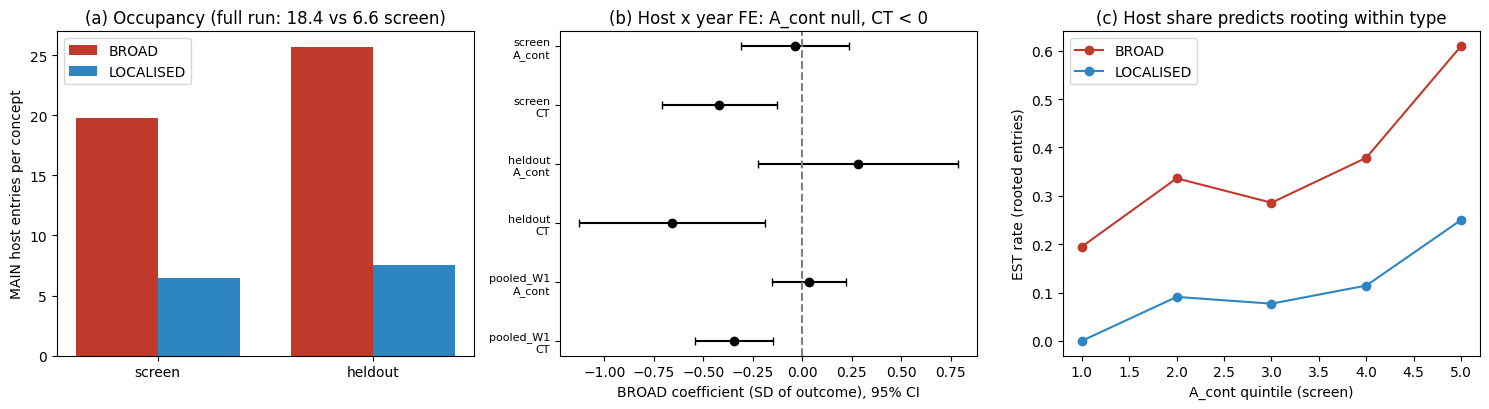

In [16]:
FULL_RUN = {  # full-run values from results/rooting.json of the evaluation (184 screen / 93 held-out concepts, B=2000)
    ("screen", "A_cont"): -0.0018, ("screen", "CT"): -0.126, ("heldout", "A_cont"): 0.0005, ("heldout", "CT"): -0.125,
    ("pooled_W1", "CT"): -0.109}

rows = []
for pop in ("screen", "heldout"):
    dsc = out[pop]["descriptives"]
    for t in ("BROAD", "LOCALISED"):
        g = dsc[t]
        rows.append(dict(population=pop, type=t, concepts=g["n_concepts"], entries=g["n_entries"],
                         all_main_per_concept=round(dsc["occupancy"][t]["all_main_entries_per_concept"], 1),
                         coprimary_per_concept=round(dsc["occupancy"][t]["coprimary_entries_per_concept"], 1),
                         A_cont=round(g["A_cont_mean"]["est"], 4), CT=round(g["CT_mean"]["est"], 3),
                         EST_rate=round(g["EST_rate"]["est"], 3) if "EST_rate" in g else None,
                         rooted_share=round(g["rooted_share"]["est"], 3) if "rooted_share" in g else None))
print("Per-type descriptives (EST / rooted share are W2 outcomes: screen only)")
print(pd.DataFrame(rows).to_string(index=False))

rows = []
for pop in ("screen", "heldout", "pooled_W1"):
    for y, key in (("A_cont", "model_i_Acont"), ("CT", "model_ii_CT")):
        m = out[pop][key]
        rows.append(dict(population=pop, outcome=y, n=m["n"], BROAD_coef=round(m["coef"], 4),
                         ci=f"[{m['ci'][0]:.4f}, {m['ci'][1]:.4f}]", p=round(m["p"], 4), full_run_coef=FULL_RUN.get((pop, y))))
print("\nAdjusted BROAD - LOCALISED gap (host x entry-year FE, concept-clustered SE)")
print(pd.DataFrame(rows).to_string(index=False))

pp = out["screen"]["model_iii_ppml"]
if "BROAD" in pp:
    print(f"\nPPML (screen): IRR per SD of A_cont  BROAD {pp['BROAD']['irr_per_sd']:.2f} {np.round(pp['BROAD']['ci'], 2)} | "
          f"LOCALISED {pp['LOCALISED']['irr_per_sd']:.2f} {np.round(pp['LOCALISED']['ci'], 2)} | interaction p = {pp['interaction_p']:.3f} "
          f"(full run: 1.36 vs 1.16, p = 0.11)")
else:
    print("\nPPML (screen):", pp)
print(f"\nHeld-out rule for the declared 'BROAD higher A_cont' prediction: holds = {out['heldout']['prediction_holds']}, "
      f"declared direction confirmed = {out['heldout']['declared_direction_confirmed']}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
cols = {"BROAD": "#c0392b", "LOCALISED": "#2e86c1"}
# (a) occupancy
pops = ["screen", "heldout"]
x = np.arange(len(pops))
for i, t in enumerate(("BROAD", "LOCALISED")):
    v = [out[p]["descriptives"]["occupancy"][t]["all_main_entries_per_concept"] for p in pops]
    ax[0].bar(x + (i - 0.5) * 0.38, v, 0.38, color=cols[t], label=t)
ax[0].set_xticks(x, pops); ax[0].set_ylabel("MAIN host entries per concept"); ax[0].set_title("(a) Occupancy (full run: 18.4 vs 6.6 screen)"); ax[0].legend()
# (b) adjusted coefficients with CI
labels, est, lo, hi_ = [], [], [], []
for pop in ("screen", "heldout", "pooled_W1"):
    for y, key in (("A_cont", "model_i_Acont"), ("CT", "model_ii_CT")):
        m = out[pop][key]
        labels.append(f"{pop}\n{y}"); est.append(m["coef_in_sd"]); lo.append(m["ci"][0] / m["sd_y"]); hi_.append(m["ci"][1] / m["sd_y"])
yy = np.arange(len(labels))
ax[1].errorbar(est, yy, xerr=[np.array(est) - lo, np.array(hi_) - est], fmt="o", color="k", capsize=3)
ax[1].axvline(0, color="grey", ls="--"); ax[1].set_yticks(yy, labels, fontsize=8); ax[1].invert_yaxis()
ax[1].set_xlabel("BROAD coefficient (SD of outcome), 95% CI"); ax[1].set_title("(b) Host x year FE: A_cont null, CT < 0")
# (c) EST rate by A_cont quintile x type (screen)
for t in ("BROAD", "LOCALISED"):
    q = [out["screen"]["EST_by_Aq_type"].get(f"{t}_q{k}", {}).get("EST_rate", np.nan) for k in range(1, 6)]
    ax[2].plot(range(1, 6), q, "o-", color=cols[t], label=t)
ax[2].set_xlabel("A_cont quintile (screen)"); ax[2].set_ylabel("EST rate (rooted entries)"); ax[2].set_title("(c) Host share predicts rooting within type")
ax[2].legend()
plt.tight_layout(); plt.show()